In [1]:
pip install soundfile numpy scipy matplotlib

In [2]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt
import soundfile as sf

In [ ]:
def comb_reverb(x, a, D):
    """
    Comb filter reverberator: y[n] = x[n] + a*y[n-D]
    Implemented as an IIR filter with feedback coefficient at lag D.
    """
    b = np.zeros(1)
    b[0] = 1.0
    a_coeffs = np.zeros(D + 1)
    a_coeffs[0] = 1.0
    a_coeffs[D] = -a
    y = lfilter(b, a_coeffs, x)
    return y

def allpass_reverb(x, a, D):
    """
    Allpass reverberator: y[n] = -a*x[n] + x[n-D] + a*y[n-D]
    """
    b = np.zeros(D + 1)
    b[0] = -a
    b[D] = 1.0
    a_coeffs = np.zeros(D + 1)
    a_coeffs[0] = 1.0
    a_coeffs[D] = -a
    y = lfilter(b, a_coeffs, x)
    return y

In [ ]:
fs = 48000
delay_ms = 40  # try values between ~20 and ~50 ms
D = int(fs * delay_ms / 1000)  # e.g. 40 ms -> 1920 samples
a = 0.7  # feedback gain; must satisfy |a| < 1 for stability
          # closer to 1 -> longer, denser decay (more reverberant)
          # smaller a -> shorter, sparser echoes

print(f"Using D = {D} samples ({delay_ms} ms at {fs} Hz), a = {a}")


Using D = 1920 samples (40 ms at 48000 Hz), a = 0.7


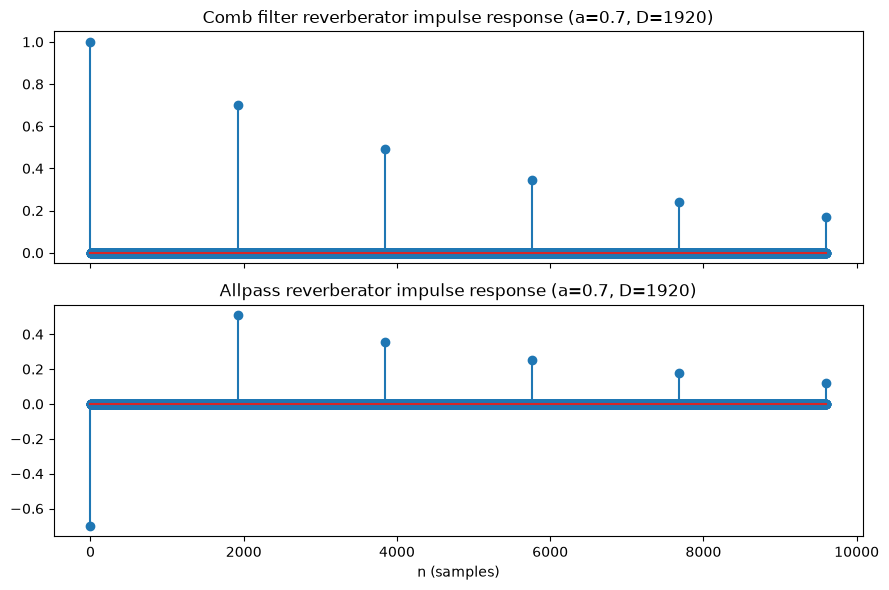

In [6]:
N = 5 * D + 1  # show several echoes
impulse = np.zeros(N)
impulse[0] = 1.0
 
h_comb = comb_reverb(impulse, a, D)
h_allpass = allpass_reverb(impulse, a, D)
 
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].stem(h_comb)
axs[0].set_title(f"Comb filter reverberator impulse response (a={a}, D={D})")
axs[1].stem(h_allpass)
axs[1].set_title(f"Allpass reverberator impulse response (a={a}, D={D})")
axs[1].set_xlabel("n (samples)")
plt.tight_layout()
plt.savefig("impulse_responses.png", dpi=150)
plt.show()


In [7]:
infile = "Music_sample_1(48kHz).wavx"
x, fs_in = sf.read(infile)
if x.ndim > 1:
    x = x.mean(axis=1)  # mix to mono if stereo
if fs_in != fs:
    print(f"Warning: file sample rate is {fs_in}, expected {fs}. "
          f"Update `fs`/`D` accordingly or resample.")

y_comb = comb_reverb(x, a, D)
y_allpass = allpass_reverb(x, a, D)

# Normalize to avoid clipping when saving
def norm(y):
    peak = np.max(np.abs(y))
    return y / peak * 0.99 if peak > 0 else y

sf.write("music_comb.wav", norm(y_comb), fs)
sf.write("music_allpass.wav", norm(y_allpass), fs)
print("Wrote music_comb.wav and music_allpass.wav")

# Optional: play back directly (uncomment if running locally with
# a working audio device; sounddevice does not work in this hosted
# environment, only on your own machine)
#
# import sounddevice as sd
# sd.play(x, fs); sd.wait()
# sd.play(norm(y_comb), fs); sd.wait()
# sd.play(norm(y_allpass), fs); sd.wait()


Wrote music_comb.wav and music_allpass.wav
